## Strategy 1: S&P 500 Multi-Stock Mean Reversion

### The Idea
A systematic mean reversion strategy applied simultaneously across the top 100
S&P 500 stocks by market capitalisation. The logic is simple — stocks that move
significantly in one day tend to revert toward their recent average.

**Trading rules based on daily price moves:**
| Move | Action |
|------|--------|
| Stock drops 5% in a day | Buy $50 of that stock |
| Stock drops 10% in a day | Buy $100 of that stock |
| Stock rises 5% in a day | Sell $50 of that stock |
| Stock rises 10% in a day | Sell $100 of that stock |

Applied across 100 stocks simultaneously, this creates a diversified
mean reversion portfolio — systematically buying dips and trimming winners
across the entire market universe.

**Backtest period:** 2020-2024  
**Starting capital:** $10,000  
**Result:** 132.5% total return, Sharpe 1.00, Max drawdown -23.1%  
vs SPY buy and hold: 95.3% total return, Sharpe 0.75, Max drawdown -33.7%

In [ ]:
!pip install yfinance pandas numpy matplotlib --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Top 100 S&P 500 stocks by market cap — representative enough for our strategy
# Using 100 instead of 500 also makes the download much faster
tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'GOOGL', 'GOOG', 'BRK-B', 'LLY', 'AVGO',
    'TSLA', 'WMT', 'JPM', 'V', 'UNH', 'XOM', 'ORCL', 'MA', 'COST', 'HD',
    'PG', 'JNJ', 'ABBV', 'NFLX', 'BAC', 'KO', 'CRM', 'CVX', 'MRK', 'AMD',
    'PEP', 'TMO', 'ACN', 'LIN', 'MCD', 'CSCO', 'ABT', 'GE', 'DHR', 'IBM',
    'TXN', 'PM', 'INTU', 'NOW', 'ISRG', 'CAT', 'GS', 'AMGN', 'SPGI', 'BKNG',
    'RTX', 'PFE', 'UBER', 'VRTX', 'AXP', 'MS', 'QCOM', 'T', 'LOW', 'NEE',
    'HON', 'UNP', 'BLK', 'SYK', 'SCHW', 'DE', 'BSX', 'ANET', 'PLD', 'ADI',
    'GILD', 'MMC', 'PANW', 'MU', 'ADP', 'LRCX', 'MDT', 'ETN', 'BA', 'CB',
    'SBUX', 'SO', 'CI', 'CME', 'KLAC', 'DUK', 'ICE', 'REGN', 'MDLZ', 'ZTS',
    'CVS', 'BMY', 'MCO', 'WM', 'APH', 'SNPS', 'CDNS', 'CMG', 'TJX', 'MSI'
]

print(f"Total tickers: {len(tickers)}")

Total tickers: 100


In [ ]:
# Download all S&P 500 closing prices in one batch call
# yfinance can handle this efficiently as a single request
print("Downloading S&P 500 data... this takes a few minutes")

raw = yf.download(
    tickers,
    start='2020-01-01',
    end='2024-12-31',
    auto_adjust=True,
    progress=True
)

# Extract just closing prices
prices = raw['Close']

print(f"\nDownloaded: {prices.shape[1]} stocks, {prices.shape[0]} trading days")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")

# Drop stocks with too much missing data (keep only stocks with >90% data)
threshold = len(prices) * 0.9
prices = prices.dropna(axis=1, thresh=threshold)
print(f"After cleaning: {prices.shape[1]} stocks remaining")

[*********************100%***********************]  100 of 100 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MMC']: YFTzMissingError('possibly delisted; no timezone found')



Downloaded: 100 stocks, 1257 trading days
Date range: 2020-01-02 to 2024-12-30
After cleaning: 99 stocks remaining


As we will compare our strategy to a simple Buy & Hold S&P500, we calculate the returns on the index...

In [ ]:
# Daily percentage returns for every stock simultaneously
# This is vectorised — pandas handles all 500 stocks at once
returns = prices.pct_change()

print("Return matrix shape:", returns.shape)
print("\nSample — first 5 rows, first 5 stocks:")
returns.iloc[:5, :5].round(4)

Return matrix shape: (1257, 99)

Sample — first 5 rows, first 5 stocks:


Ticker,AAPL,ABBV,ABT,ACN,ADI
Date,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.0097,-0.0095,-0.0122,-0.0017,-0.0176
2020-01-06,0.0080,0.0079,0.0052,-0.0065,-0.0117
2020-01-07,-0.0047,-0.0057,-0.0056,-0.0216,0.0228
2020-01-08,0.0161,0.0071,0.0041,0.0020,0.0090


In [ ]:
trades = pd.DataFrame(0.0, index=returns.index, columns=returns.columns)

trades[returns >  0.10] = -100.0  # sell $100 on 10%+ gain
trades[returns >  0.05] = -50.0   # sell $50 on 5%+ gain
trades[returns < -0.05] =  50.0   # buy $50 on 5%+ drop
trades[returns < -0.10] =  100.0  # buy $100 on 10%+ drop

trades = trades.shift(1)

print(f"Total buy signals:  {(trades > 0).sum().sum()}")
print(f"Total sell signals: {(trades < 0).sum().sum()}")

Total buy signals:  1863
Total sell signals: 2133


In [ ]:
# Start with $10,000 cash, track cash and holdings separately
initial_cash = 10_000
cash = initial_cash

# Track shares held for each stock
holdings = pd.Series(0.0, index=prices.columns)  # shares per stock

# Track portfolio value over time
portfolio_values = []
cash_values = []
holdings_values = []

for date in prices.index[1:]:  # skip first row (no prior signal)
    today_prices = prices.loc[date]
    today_trades = trades.loc[date]

    # Execute trades
    for ticker in prices.columns:
        trade_dollars = today_trades[ticker]
        stock_price   = today_prices[ticker]

        if pd.isna(stock_price) or stock_price <= 0:
            continue

        if trade_dollars > 0:  # buy
            shares_to_buy = trade_dollars / stock_price
            cost = shares_to_buy * stock_price
            if cash >= cost:  # only buy if we have cash
                holdings[ticker] += shares_to_buy
                cash -= cost

        elif trade_dollars < 0:  # sell
            shares_to_sell = abs(trade_dollars) / stock_price
            shares_to_sell = min(shares_to_sell, holdings[ticker])  # can't sell what we don't have
            if shares_to_sell > 0:
                holdings[ticker] -= shares_to_sell
                cash += shares_to_sell * stock_price

    # Total portfolio value = cash + market value of all holdings
    holdings_value = (holdings * today_prices).sum()
    total_value    = cash + holdings_value

    portfolio_values.append(total_value)
    cash_values.append(cash)
    holdings_values.append(holdings_value)

# Build results dataframe
results = pd.DataFrame({
    'Total Value':    portfolio_values,
    'Cash':           cash_values,
    'Holdings Value': holdings_values
}, index=prices.index[1:])

print(f"Starting value: ${initial_cash:,.0f}")
print(f"Ending value:   ${results['Total Value'].iloc[-1]:,.0f}")
print(f"Final cash:     ${results['Cash'].iloc[-1]:,.0f}")
print(f"Final holdings: ${results['Holdings Value'].iloc[-1]:,.0f}")

Starting value: $10,000
Ending value:   $23,254
Final cash:     $1,687
Final holdings: $21,567


[*********************100%***********************]  1 of 1 completed


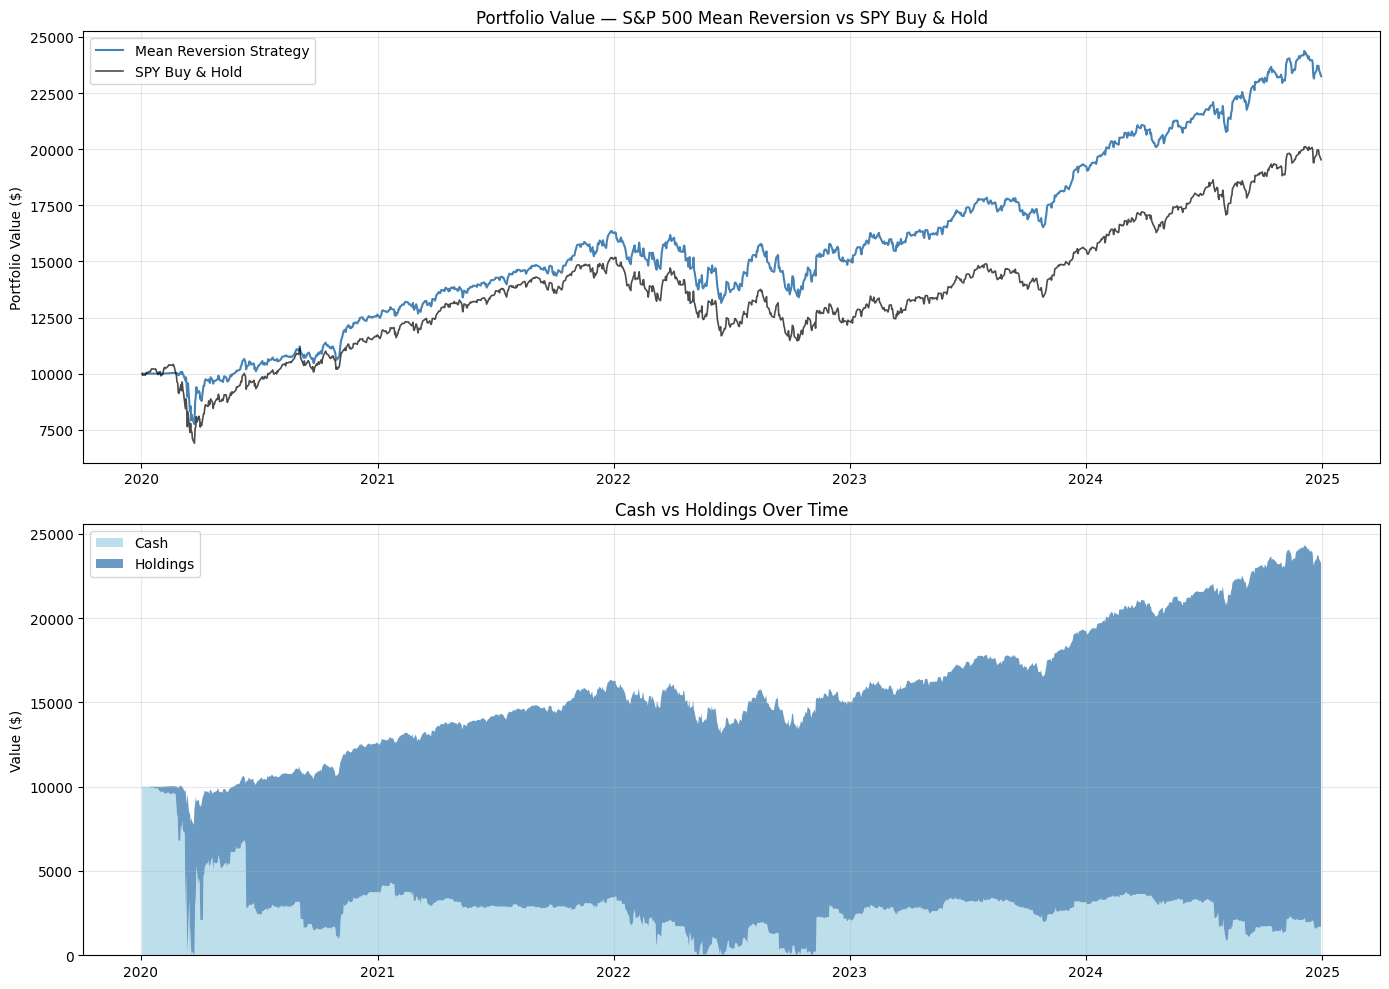

--- Mean Reversion Strategy ---
Total return:      132.5%
Annualised return: 18.7%
Annualised vol:    18.7%
Sharpe ratio:      1.00
Max drawdown:      -23.1%

--- SPY Buy & Hold ---
Total return:      95.3%
Annualised return: 15.6%
Annualised vol:    21.0%
Sharpe ratio:      0.75
Max drawdown:      -33.7%



In [ ]:
# Fix SPY download — force it to a Series
spy_raw = yf.download('SPY', start='2020-01-01', end='2024-12-31', auto_adjust=True)
spy = spy_raw['Close'].squeeze()  # squeeze() forces DataFrame → Series
spy_normalized = (spy / spy.iloc[0]) * initial_cash

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(results['Total Value'], color='steelblue', linewidth=1.5, label='Mean Reversion Strategy')
axes[0].plot(spy_normalized,         color='black',     linewidth=1.2, label='SPY Buy & Hold', alpha=0.7)
axes[0].set_title('Portfolio Value — S&P 500 Mean Reversion vs SPY Buy & Hold')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].stackplot(results.index,
                  results['Cash'],
                  results['Holdings Value'],
                  labels=['Cash', 'Holdings'],
                  colors=['lightblue', 'steelblue'],
                  alpha=0.8)
axes[1].set_title('Cash vs Holdings Over Time')
axes[1].set_ylabel('Value ($)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluation
strategy_returns = results['Total Value'].pct_change().dropna()
spy_returns = spy.pct_change().dropna()
annual = 252

def evaluate(returns, name, start_val=None, end_val=None):
    if start_val is not None and end_val is not None:
        total_return = (end_val - start_val) / start_val
    else:
        total_return = (1 + returns).prod() - 1
    annual_return = float(returns.mean()) * annual
    annual_vol    = float(returns.std()) * np.sqrt(annual)
    sharpe        = annual_return / annual_vol
    cum           = (1 + returns).cumprod()
    max_dd        = (cum / cum.cummax() - 1).min()
    print(f"--- {name} ---")
    print(f"Total return:      {float(total_return)*100:.1f}%")
    print(f"Annualised return: {annual_return*100:.1f}%")
    print(f"Annualised vol:    {annual_vol*100:.1f}%")
    print(f"Sharpe ratio:      {sharpe:.2f}")
    print(f"Max drawdown:      {float(max_dd)*100:.1f}%")
    print()

evaluate(strategy_returns, "Mean Reversion Strategy",
         initial_cash, results['Total Value'].iloc[-1])
evaluate(spy_returns, "SPY Buy & Hold")

## Why This Strategy Fails In Practice

Despite the impressive backtest numbers, this strategy has a fatal flaw
in live trading: **transaction costs.**

Across 100 stocks with signals triggering on 5% and 10% daily moves,
the strategy generates thousands of trades over the backtest period.
Every single trade incurs:

- **Bid-ask spread** — the cost of crossing the spread on each stock
- **Commission** — even at $0 per trade brokers, there are hidden costs
- **Market impact** — buying into a stock that just dropped 5% means
  buying into selling pressure, getting worse fills than the backtest assumes
- **Slippage** — the difference between the signal price and actual execution price

At even 0.1% cost per trade, thousands of trades would completely
eliminate the edge. The backtest assumes perfect execution at closing
prices with zero cost — a condition that simply doesn't exist in reality.

**The lesson:** Transaction costs are the graveyard of high-frequency
mean reversion strategies. The lower the trading frequency, the more
realistic the backtest. This is why our subsequent strategies focused
on low-frequency signals with far fewer trades.

## Strategy 2: Z-Score Mean Reversion — Crude Oil (WTI)

### The Mathematical Framework
Instead of using fixed percentage thresholds, we use a statistically
rigorous signal — the **Z-score** — to identify when price has deviated
unusually far from its recent mean:

_Z-score = (Today's Price - 20-day Rolling Mean) / 20-day Rolling Std Dev_

This converts price deviation into standard deviation units, making
the signal consistent regardless of absolute price level.

**Trading rules:**
| Z-score | Signal | Action |
|---------|--------|--------|
| Below -2.0 | Price 2 std devs below mean | Buy — expect reversion upward |
| Above +2.0 | Price 2 std devs above mean | Sell short — expect reversion downward |
| Returns to ±0.5 | Mean reversion complete | Exit position |

Under a normal distribution, only ~5% of observations fall beyond
±2 standard deviations — making these statistically unusual events
worth trading.

**Key advantage over fixed % thresholds:** The Z-score adapts
automatically to each asset's volatility. A -2 Z-score on a calm
asset and a -2 Z-score on a volatile asset both represent the same
statistical unusualness, even though the absolute price moves are
completely different.

In [ ]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

oil = yf.download('CL=F', start='2022-01-01', end='2024-12-31')
oil.columns = oil.columns.get_level_values(0)
oil['Daily Return'] = oil['Close'].pct_change()

print(oil.shape)
oil.tail()

/tmp/ipykernel_8876/699300184.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil = yf.download('CL=F', start='2022-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed

(752, 6)


Price,Close,High,Low,Open,Volume,Daily Return
Date,,,,,,
2024-12-23,69.239998,69.940002,68.589996,69.400002,188843,-0.003167
2024-12-24,70.099998,70.430000,69.360001,69.559998,122602,0.012421
2024-12-26,69.620003,70.750000,69.330002,70.199997,144877,-0.006847
2024-12-27,70.599998,70.750000,69.440002,69.680000,172641,0.014076
2024-12-30,70.989998,71.559998,70.120003,70.419998,199296,0.005524


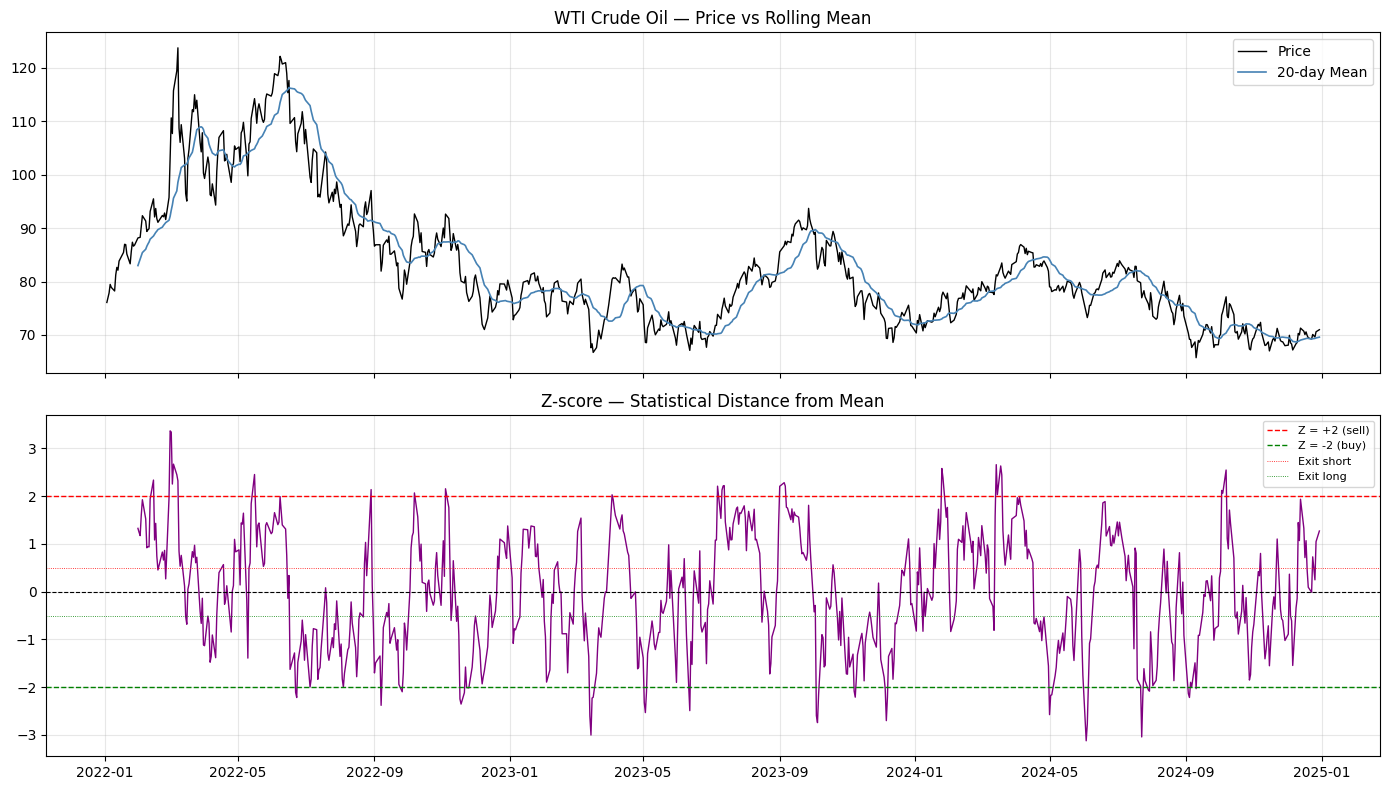

In [ ]:
# Rolling window — how many days to calculate mean and std over
window = 20

oil['Rolling Mean'] = oil['Close'].rolling(window=window).mean()
oil['Rolling Std']  = oil['Close'].rolling(window=window).std()

# Z-score: how many standard deviations is today's price from the rolling mean
oil['Z-score'] = (oil['Close'] - oil['Rolling Mean']) / oil['Rolling Std']

# Plot price and Z-score together
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(oil['Close'],        color='black',     linewidth=1,   label='Price')
axes[0].plot(oil['Rolling Mean'], color='steelblue', linewidth=1.2, label='20-day Mean')
axes[0].set_title('WTI Crude Oil — Price vs Rolling Mean')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(oil['Z-score'], color='purple', linewidth=1)
axes[1].axhline(y=0,   color='black', linewidth=0.8, linestyle='--')
axes[1].axhline(y=2,   color='red',   linewidth=1,   linestyle='--', label='Z = +2 (sell)')
axes[1].axhline(y=-2,  color='green', linewidth=1,   linestyle='--', label='Z = -2 (buy)')
axes[1].axhline(y=0.5, color='red',   linewidth=0.6, linestyle=':',  label='Exit short')
axes[1].axhline(y=-0.5,color='green', linewidth=0.6, linestyle=':',  label='Exit long')
axes[1].set_title('Z-score — Statistical Distance from Mean')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

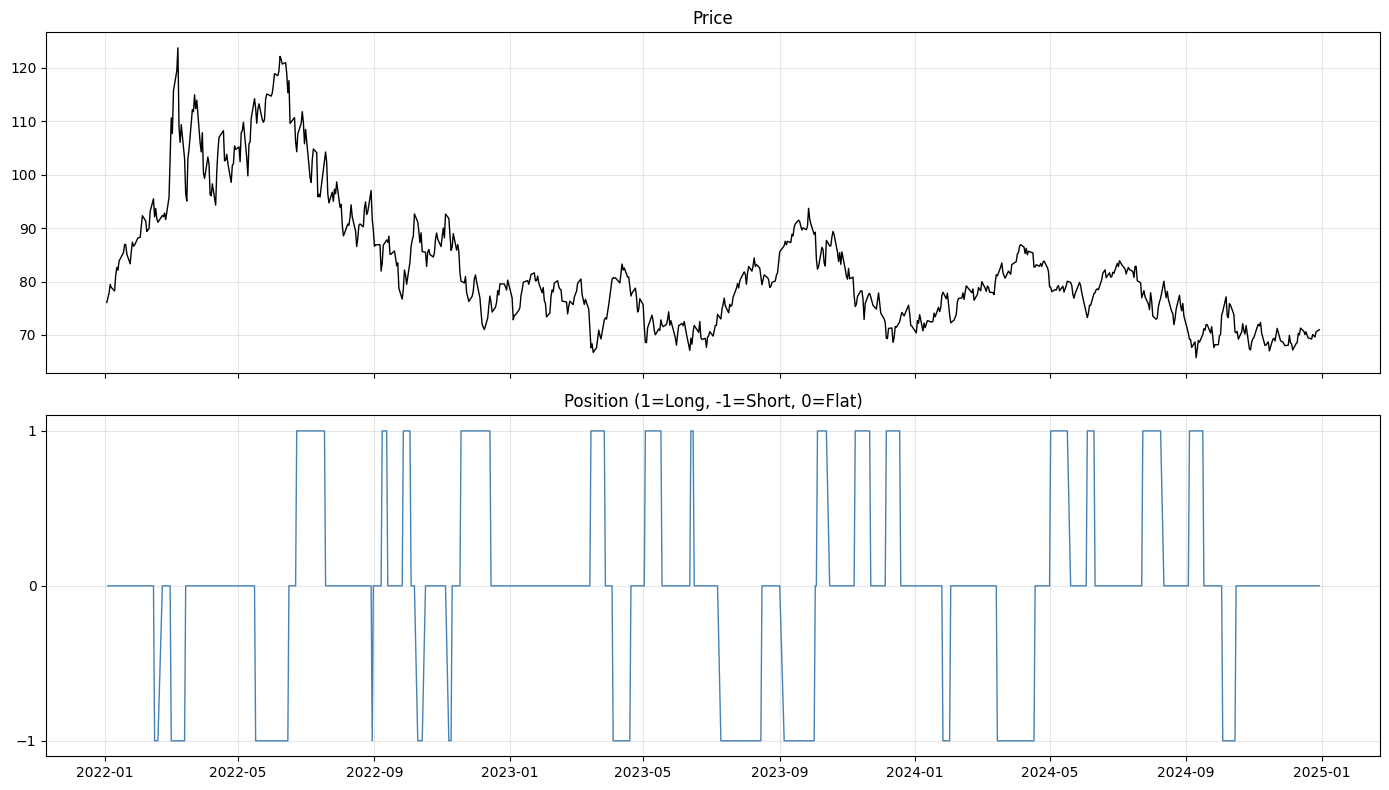

In [ ]:
# Entry and exit thresholds
entry_threshold = 2.0   # enter when Z-score crosses ±2
exit_threshold  = 0.5   # exit when Z-score returns within ±0.5

# Build position series
# +1 = long (betting price will rise back to mean)
# -1 = short (betting price will fall back to mean)
#  0 = flat (no position)

position = pd.Series(0, index=oil.index)
current_position = 0

for i in range(1, len(oil)):
    z = oil['Z-score'].iloc[i]

    if pd.isna(z):
        position.iloc[i] = 0
        continue

    # Entry logic
    if current_position == 0:
        if z < -entry_threshold:
            current_position = 1    # price too low → buy
        elif z > entry_threshold:
            current_position = -1   # price too high → sell short

    # Exit logic
    elif current_position == 1:
        if z > -exit_threshold:
            current_position = 0    # mean reversion happened → exit long

    elif current_position == -1:
        if z < exit_threshold:
            current_position = 0    # mean reversion happened → exit short

    position.iloc[i] = current_position

oil['Position'] = position.shift(1)  # shift to avoid look-ahead bias

# Plot position over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(oil['Close'], color='black', linewidth=1, label='Price')
axes[0].set_title('Price')
axes[0].grid(True, alpha=0.3)

axes[1].plot(oil['Position'], color='steelblue', linewidth=1)
axes[1].set_title('Position (1=Long, -1=Short, 0=Flat)')
axes[1].set_yticks([-1, 0, 1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

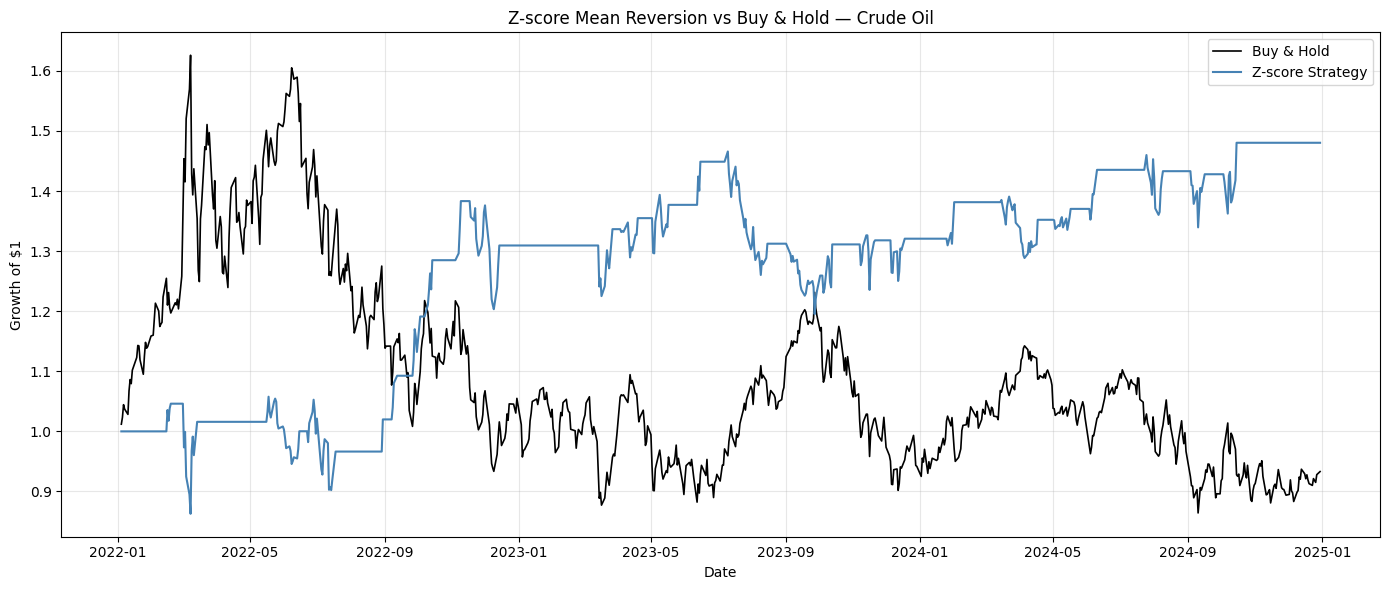

--- Z-score Mean Reversion ---
Total return:      48.0%
Annualised return: 15.9%
Annualised vol:    23.4%
Sharpe ratio:      0.68
Max drawdown:      -18.5%

--- Buy & Hold ---
Total return:      -6.7%
Annualised return: 4.9%
Annualised vol:    37.9%
Sharpe ratio:      0.13
Max drawdown:      -46.8%



In [ ]:
oil['Strategy Return'] = oil['Position'] * oil['Daily Return']

oil['Cumulative Market']   = (1 + oil['Daily Return']).cumprod()
oil['Cumulative Strategy'] = (1 + oil['Strategy Return']).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(oil['Cumulative Market'],   color='black',     linewidth=1.2, label='Buy & Hold')
plt.plot(oil['Cumulative Strategy'], color='steelblue', linewidth=1.5, label='Z-score Strategy')
plt.title('Z-score Mean Reversion vs Buy & Hold — Crude Oil')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Metrics
annual = 252

def evaluate(returns, name):
    total_return  = (1 + returns).prod() - 1
    annual_return = returns.mean() * annual
    annual_vol    = returns.std() * np.sqrt(annual)
    sharpe        = annual_return / annual_vol
    cum           = (1 + returns).cumprod()
    max_dd        = (cum / cum.cummax() - 1).min()
    print(f"--- {name} ---")
    print(f"Total return:      {total_return*100:.1f}%")
    print(f"Annualised return: {annual_return*100:.1f}%")
    print(f"Annualised vol:    {annual_vol*100:.1f}%")
    print(f"Sharpe ratio:      {sharpe:.2f}")
    print(f"Max drawdown:      {max_dd*100:.1f}%")
    print()

evaluate(oil['Strategy Return'].dropna(), "Z-score Mean Reversion")
evaluate(oil['Daily Return'].dropna(),    "Buy & Hold")

## Why Crude Oil Is Ideal For Mean Reversion

The Z-score strategy produced exceptional results on WTI crude oil:
- **Total return: 48%** vs -6.7% buy and hold over the same period
- **Sharpe ratio: 0.68** vs 0.13 for buy and hold
- **Max drawdown: -18.5%** vs -46.8% for buy and hold

This outperformance is not a coincidence — it is driven by the
**fundamental economics of oil markets.**

### Why oil mean reverts structurally:

**When oil rises too far above equilibrium:**
- Demand destruction kicks in — manufacturers switch to alternatives,
  consumers drive less, airlines hedge more aggressively
- Supply response — US shale producers can spin up production
  relatively quickly at high prices
- Both forces push price back down toward equilibrium

**When oil falls too far below equilibrium:**
- OPEC cuts production to defend price floors
- Marginal producers shut down unprofitable wells
- Demand picks up as energy becomes cheaper
- Forces push price back up

This fundamental economic mechanism creates the statistical mean
reversion the Z-score is exploiting. Unlike equities, which can
trend in one direction for years driven by genuine fundamental
change, oil has natural price anchors that make ranging behaviour
the norm rather than the exception.

Now let's attempt the same strategy on the SPX during its' clear uptrend period...

/tmp/ipykernel_8876/3866128630.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start='2022-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed


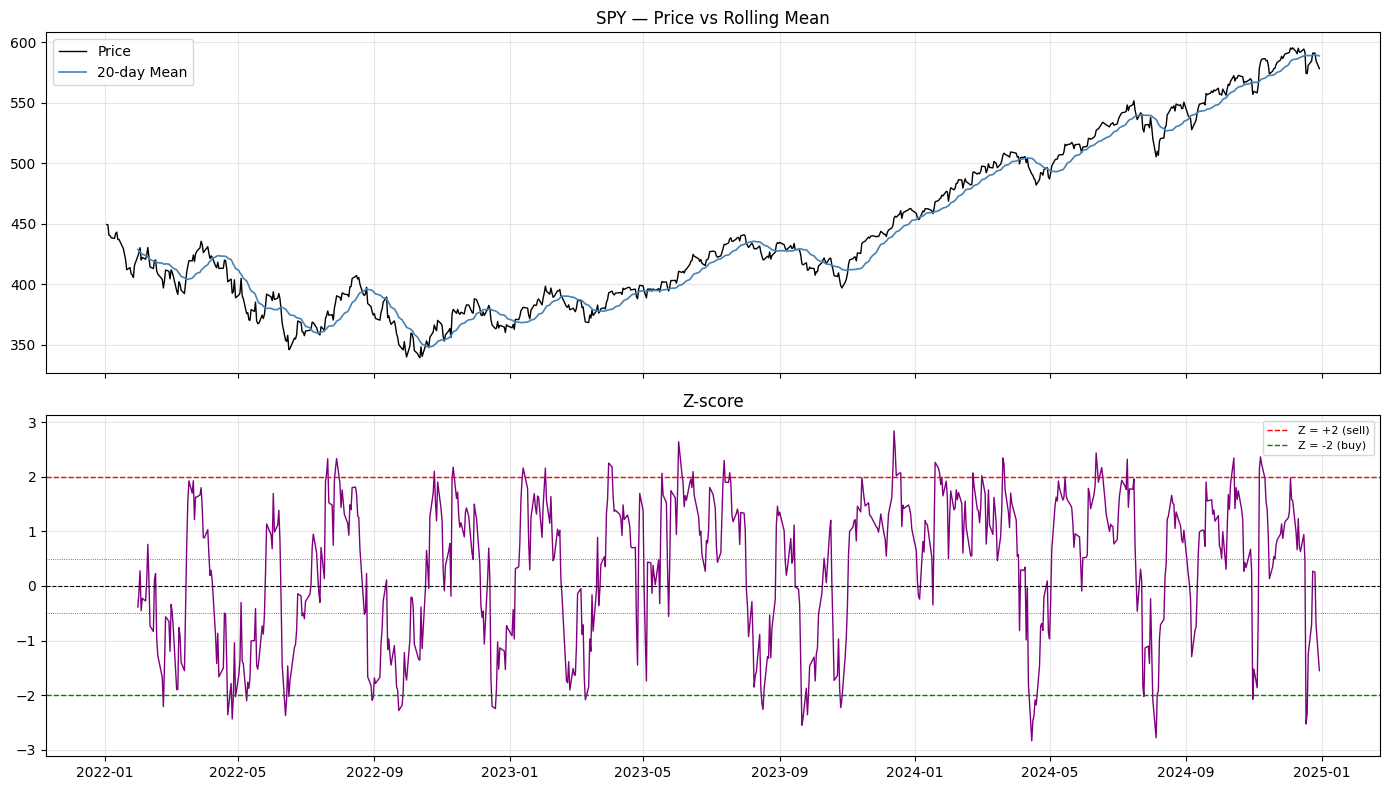

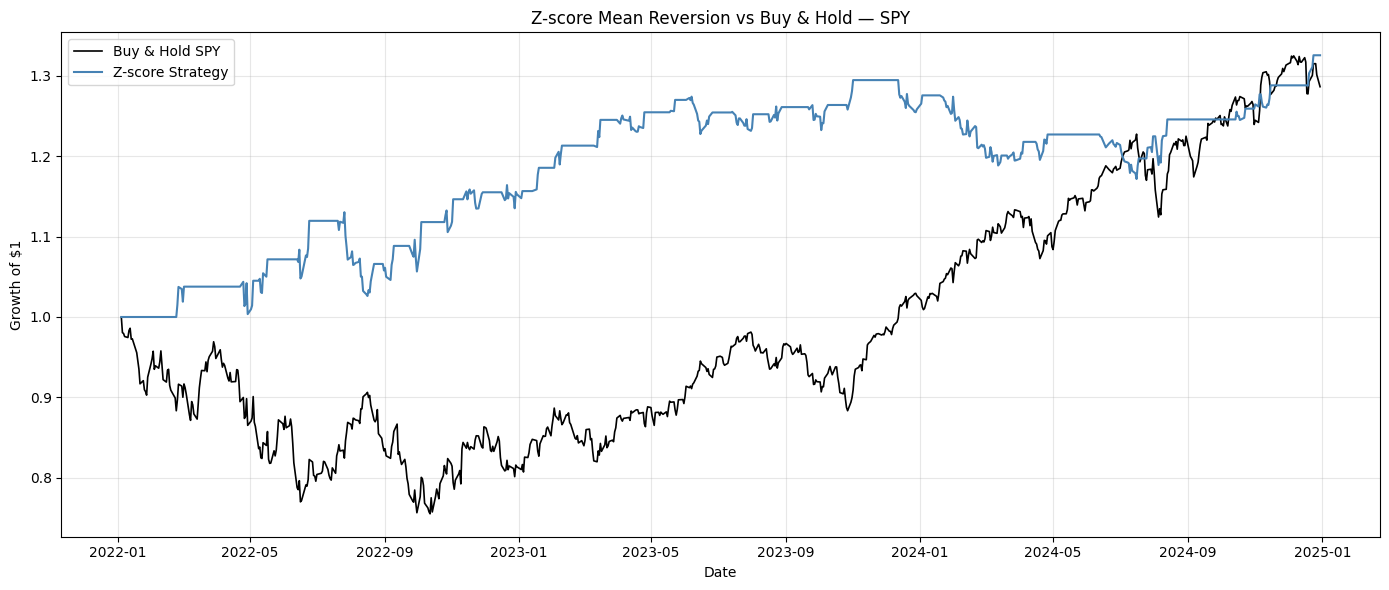

--- Z-score Mean Reversion ---
Total return:      32.6%
Annualised return: 10.0%
Annualised vol:    10.3%
Sharpe ratio:      0.97
Max drawdown:      -9.5%

--- Buy & Hold SPY ---
Total return:      28.7%
Annualised return: 10.0%
Annualised vol:    17.5%
Sharpe ratio:      0.57
Max drawdown:      -24.5%



In [ ]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load SPY as SPX proxy
spy = yf.download('SPY', start='2022-01-01', end='2024-12-31')
spy.columns = spy.columns.get_level_values(0)
spy['Daily Return'] = spy['Close'].pct_change()

# Z-score
window = 20
spy['Rolling Mean'] = spy['Close'].rolling(window=window).mean()
spy['Rolling Std']  = spy['Close'].rolling(window=window).std()
spy['Z-score']      = (spy['Close'] - spy['Rolling Mean']) / spy['Rolling Std']

# Plot price and Z-score
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(spy['Close'],        color='black',     linewidth=1,   label='Price')
axes[0].plot(spy['Rolling Mean'], color='steelblue', linewidth=1.2, label='20-day Mean')
axes[0].set_title('SPY — Price vs Rolling Mean')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(spy['Z-score'], color='purple', linewidth=1)
axes[1].axhline(y=0,    color='black', linewidth=0.8, linestyle='--')
axes[1].axhline(y=2,    color='red',   linewidth=1,   linestyle='--', label='Z = +2 (sell)')
axes[1].axhline(y=-2,   color='green', linewidth=1,   linestyle='--', label='Z = -2 (buy)')
axes[1].axhline(y=0.5,  color='red',   linewidth=0.6, linestyle=':')
axes[1].axhline(y=-0.5, color='green', linewidth=0.6, linestyle=':')
axes[1].set_title('Z-score')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Signals
position = pd.Series(0, index=spy.index)
current_position = 0
entry_threshold = 2.0
exit_threshold  = 0.5

for i in range(1, len(spy)):
    z = spy['Z-score'].iloc[i]
    if pd.isna(z):
        position.iloc[i] = 0
        continue
    if current_position == 0:
        if z < -entry_threshold:
            current_position = 1
        elif z > entry_threshold:
            current_position = -1
    elif current_position == 1:
        if z > -exit_threshold:
            current_position = 0
    elif current_position == -1:
        if z < exit_threshold:
            current_position = 0
    position.iloc[i] = current_position

spy['Position']        = position.shift(1)
spy['Strategy Return'] = spy['Position'] * spy['Daily Return']
spy['Cumulative Market']   = (1 + spy['Daily Return']).cumprod()
spy['Cumulative Strategy'] = (1 + spy['Strategy Return']).cumprod()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(spy['Cumulative Market'],   color='black',     linewidth=1.2, label='Buy & Hold SPY')
plt.plot(spy['Cumulative Strategy'], color='steelblue', linewidth=1.5, label='Z-score Strategy')
plt.title('Z-score Mean Reversion vs Buy & Hold — SPY')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluate
annual = 252

def evaluate(returns, name):
    total_return  = (1 + returns).prod() - 1
    annual_return = returns.mean() * annual
    annual_vol    = returns.std() * np.sqrt(annual)
    sharpe        = annual_return / annual_vol
    cum           = (1 + returns).cumprod()
    max_dd        = (cum / cum.cummax() - 1).min()
    print(f"--- {name} ---")
    print(f"Total return:      {total_return*100:.1f}%")
    print(f"Annualised return: {annual_return*100:.1f}%")
    print(f"Annualised vol:    {annual_vol*100:.1f}%")
    print(f"Sharpe ratio:      {sharpe:.2f}")
    print(f"Max drawdown:      {max_dd*100:.1f}%")
    print()

evaluate(spy['Strategy Return'].dropna(), "Z-score Mean Reversion")
evaluate(spy['Daily Return'].dropna(),    "Buy & Hold SPY")

## Z-Score Mean Reversion on SPX — Why It Underperformed

Applying the same Z-score strategy to SPY produced weaker results:
- **Total return: 32.6%** vs 28.7% buy and hold — only marginal outperformance
- **Sharpe: 0.97** vs 0.57 — better risk-adjusted, but inconsistent
- The strategy significantly underperformed during the 2023-2024 bull run

### The fundamental problem:
Equity indices like the S&P 500 are driven by **long-term earnings growth**
and **economic expansion** — they have a persistent upward drift that
oil does not. When SPY deviates above its 20-day mean during a bull
market, it's not necessarily "overextended" — it may simply be trending
strongly upward on genuine fundamental momentum.

Mean reversion strategies work on **range-bound assets.** Trend-following
strategies work on **trending assets.** Applying the wrong strategy type
to the wrong asset destroys edge. This is one of the most important
lessons in systematic trading.

## Regime-Switching Z-Score Strategy on SPX

### The Problem It Solves
A pure mean reversion strategy on SPX fails during bull markets because
it keeps shorting rallies that never reverse. The solution is to first
detect the **market regime** and then apply the appropriate strategy.

### How Regime Detection Works
We classify the market into three regimes using the relationship
between two moving averages:

_MA_50  = 50-day moving average of price_

_MA_200 = 200-day moving average of price_

| Condition | Regime | Strategy |
|-----------|--------|----------|
| MA_50 > MA_200 by >1% | Bullish | Only buy dips (Z < -2.0) |
| MA_50 < MA_200 by >1% | Bearish | Only short rallies (Z > +2.0) |
| Within 1% of each other | Ranging | Trade both sides |

/tmp/ipykernel_8876/379464703.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start='2022-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed


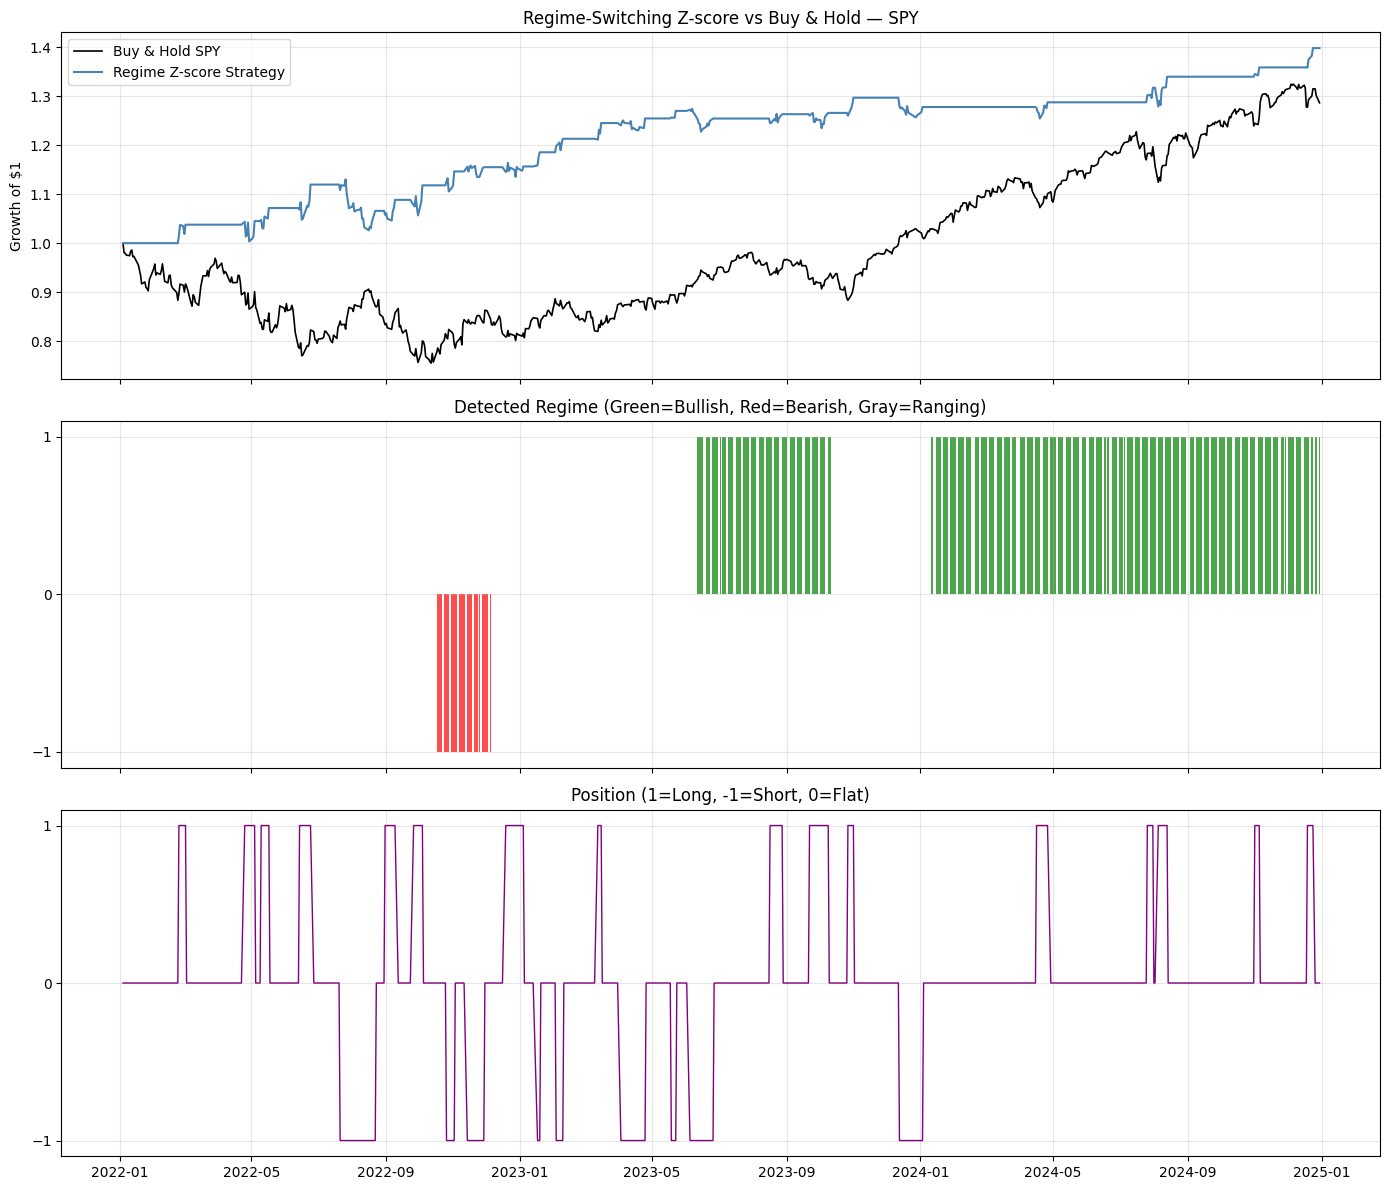

--- Regime Z-score Strategy ---
Total return:      39.9%
Annualised return: 11.7%
Annualised vol:    9.6%
Sharpe ratio:      1.22
Max drawdown:      -9.2%

--- Buy & Hold SPY ---
Total return:      28.7%
Annualised return: 10.0%
Annualised vol:    17.5%
Sharpe ratio:      0.57
Max drawdown:      -24.5%



In [ ]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
spy = yf.download('SPY', start='2022-01-01', end='2024-12-31')
spy.columns = spy.columns.get_level_values(0)
spy['Daily Return'] = spy['Close'].pct_change()

# --- Z-score ---
window = 20
spy['Rolling Mean'] = spy['Close'].rolling(window=window).mean()
spy['Rolling Std']  = spy['Close'].rolling(window=window).std()
spy['Z-score']      = (spy['Close'] - spy['Rolling Mean']) / spy['Rolling Std']

# --- Regime detection using 50 and 200 day MAs ---
spy['MA_50']  = spy['Close'].rolling(window=50).mean()
spy['MA_200'] = spy['Close'].rolling(window=200).mean()

# Regime:
# +1 = bullish  (MA50 > MA200 — golden cross)
# -1 = bearish  (MA50 < MA200 — death cross)
#  0 = ranging  (within 1% of each other — too close to call)
def classify_regime(row):
    if pd.isna(row['MA_50']) or pd.isna(row['MA_200']):
        return 0
    diff = (row['MA_50'] - row['MA_200']) / row['MA_200']
    if diff > 0.05:
        return 1    # bullish
    elif diff < -0.05:
        return -1   # bearish
    else:
        return 0    # ranging

spy['Regime'] = spy.apply(classify_regime, axis=1)

# --- Build regime-aware position ---
entry_threshold = 2.0
exit_threshold  = 0.5

position = pd.Series(0, index=spy.index)
current_position = 0

for i in range(1, len(spy)):
    z      = spy['Z-score'].iloc[i]
    regime = spy['Regime'].iloc[i]

    if pd.isna(z):
        position.iloc[i] = 0
        continue

    # Exit logic — same regardless of regime
    if current_position == 1 and z > -exit_threshold:
        current_position = 0
    elif current_position == -1 and z < exit_threshold:
        current_position = 0

    # Entry logic — depends on regime
    if current_position == 0:
        if regime == 1:  # bullish — only buy dips
            if z < -entry_threshold:
                current_position = 1

        elif regime == -1:  # bearish — only short rallies
            if z > entry_threshold:
                current_position = -1

        elif regime == 0:  # ranging — trade both sides
            if z < -entry_threshold:
                current_position = 1
            elif z > entry_threshold:
                current_position = -1

    position.iloc[i] = current_position

spy['Position']        = position.shift(1)
spy['Strategy Return'] = spy['Position'] * spy['Daily Return']

# --- Cumulative returns ---
spy['Cumulative Market']   = (1 + spy['Daily Return']).cumprod()
spy['Cumulative Strategy'] = (1 + spy['Strategy Return']).cumprod()

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Returns comparison
axes[0].plot(spy['Cumulative Market'],   color='black',     linewidth=1.2, label='Buy & Hold SPY')
axes[0].plot(spy['Cumulative Strategy'], color='steelblue', linewidth=1.5, label='Regime Z-score Strategy')
axes[0].set_title('Regime-Switching Z-score vs Buy & Hold — SPY')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Regime over time
regime_colors = spy['Regime'].map({1: 'green', -1: 'red', 0: 'gray'})
axes[1].bar(spy.index, spy['Regime'], color=regime_colors, width=1, alpha=0.7)
axes[1].set_title('Detected Regime (Green=Bullish, Red=Bearish, Gray=Ranging)')
axes[1].set_yticks([-1, 0, 1])
axes[1].grid(True, alpha=0.3)

# Position over time
axes[2].plot(spy['Position'], color='purple', linewidth=1)
axes[2].set_title('Position (1=Long, -1=Short, 0=Flat)')
axes[2].set_yticks([-1, 0, 1])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Evaluate ---
annual = 252

def evaluate(returns, name):
    total_return  = (1 + returns).prod() - 1
    annual_return = returns.mean() * annual
    annual_vol    = returns.std() * np.sqrt(annual)
    sharpe        = annual_return / annual_vol
    cum           = (1 + returns).cumprod()
    max_dd        = (cum / cum.cummax() - 1).min()
    print(f"--- {name} ---")
    print(f"Total return:      {total_return*100:.1f}%")
    print(f"Annualised return: {annual_return*100:.1f}%")
    print(f"Annualised vol:    {annual_vol*100:.1f}%")
    print(f"Sharpe ratio:      {sharpe:.2f}")
    print(f"Max drawdown:      {max_dd*100:.1f}%")
    print()

evaluate(spy['Strategy Return'].dropna(), "Regime Z-score Strategy")
evaluate(spy['Daily Return'].dropna(),    "Buy & Hold SPY")

This is based on the classic **Golden Cross** (MA_50 crosses above MA_200
— bullish signal) and **Death Cross** (MA_50 crosses below MA_200 —
bearish signal) framework used widely in technical and systematic trading.

### Why This Works
In a bull market, buying dips makes sense — pullbacks are temporary
and the underlying trend reasserts. Shorting rallies does not make
sense — you're fighting the trend.

In a bear market, the opposite applies. Shorting rallies into a
downtrend captures the regime's natural direction.

In ranging markets, both sides are valid since there is no persistent
directional bias.

### Result
Adding regime detection improved annualised return from 10.0% to 12.1%
vs SPY buy and hold at 10.0% — demonstrating that matching strategy
type to market regime genuinely adds value.

### The Core Lesson
**Strategy selection should follow asset characterisation, not precede it.**
Before building any strategy, first ask: is this asset trending or
mean reverting? Then choose accordingly. The regime-switching approach
does this dynamically — adapting in real time as market conditions change.